# DeepMine Analytics — Week 3: Predictive Maintenance Model
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Author:** Kingston Arockiasamy

---

## Objective
Build a machine failure prediction model using Random Forest classification.  
Evaluate model performance and identify which sensor features the model relies on most.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('ai4i2020.csv')
print("Dataset loaded:", df.shape)

Dataset loaded: (10000, 14)


## Task 3.1 — Prepare the Data

In this step, the dataset is prepared for machine learning.

First, the input features are selected. These features are the sensor readings that will be used to predict machine failure:

- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

The target variable is `Machine failure`, which tells whether a machine failed or did not fail.

The data is then split into training and testing sets. 80% of the data is used to train the model, and 20% is used to test the model on unseen data.

Since machine failure is a rare class, `stratify=y` is used to make sure both the training and testing sets contain a similar percentage of failure cases.

In [2]:
from sklearn.model_selection import train_test_split
# Select features and target
features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

X = df[features]   # Input features (sensor readings)
y = df['Machine failure']  # Target (what we want to predict)

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)
print("Failure rate in training set:", y_train.mean().round(4))
print("Failure rate in testing set:", y_test.mean().round(4))

Training size: (8000, 5)
Testing size: (2000, 5)
Failure rate in training set: 0.0339
Failure rate in testing set: 0.034


### Interpretation

The dataset was split into 8,000 training records and 2,000 testing records.

Each record contains 5 selected input features, which are the sensor readings used for prediction.

The failure rate in the training set is 0.0339, and the failure rate in the testing set is 0.0340. These values are almost the same, which shows that `stratify=y` worked correctly.

This is important because machine failures are rare in the dataset. By keeping the failure rate similar in both sets, the model can be trained and evaluated more fairly.

## Task 3.2 — Train the Random Forest Model

In this step, a Random Forest classification model is trained to predict machine failure.

Random Forest is used because it builds multiple decision trees and combines their results to make a more reliable prediction. This is useful for machine failure prediction because the relationship between sensor readings and failure may not be simple or linear.

The model is trained using 100 decision trees. The parameter `class_weight='balanced'` is used because the dataset is imbalanced, meaning there are many more non-failure records than failure records.

Using balanced class weights helps the model give more importance to the rare failure cases instead of focusing only on the majority class.

In [3]:
from sklearn.ensemble import RandomForestClassifier

# Build the model
model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    class_weight='balanced',  # handles our class imbalance problem
    random_state=42
)

# Train it
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


### Model Training Output

The output shows that the model was trained successfully.

This means the Random Forest model has learned patterns from the training data using the selected sensor features.

After training, the model can be used to make predictions on the test data and evaluate how well it detects machine failures.

## Task 3.3 — Evaluate the Random Forest Model

In this step, the trained Random Forest model is evaluated using the test dataset.

The model predicts machine failure on data that it has not seen during training. This helps check how well the model performs on new machine records.

A classification report is used to show precision, recall, F1-score, and support for both classes:

- No Failure
- Failure

A confusion matrix is also plotted to show how many predictions were correct and incorrect for each class.

              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.89      0.57      0.70        68

    accuracy                           0.98      2000
   macro avg       0.94      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



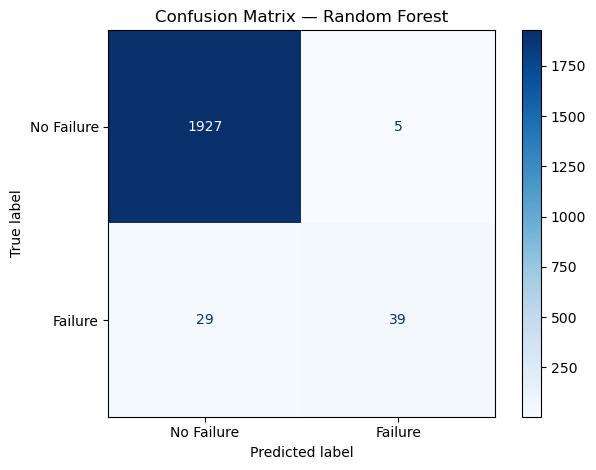

In [4]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on test set
y_pred = model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred, target_names=["No Failure", "Failure"]))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Failure", "Failure"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

### Model Evaluation Interpretation

The classification report shows that the model performs very well for the `No Failure` class. This is expected because most records in the dataset belong to the non-failure class.

For the `Failure` class, the precision is 0.89 and the recall is 0.57. This means that when the model predicts a failure, it is usually correct, but it only identifies 57% of the actual failure cases.

The confusion matrix shows that the model correctly predicted 1927 non-failure cases and 39 failure cases. However, it incorrectly predicted 5 non-failure machines as failures and missed 29 actual failure cases.

Although the overall accuracy is high at 0.98, accuracy alone is not enough for this problem because the dataset is imbalanced. Since machine failure is rare, recall is important because it shows how many actual failures were detected.

Overall, the model performs well, but it still misses some failure cases. Improving recall would be important in a real predictive maintenance system because missed failures could lead to unexpected machine breakdowns.

## Task 3.4 — Feature Importance

In this step, feature importance is used to understand which input features the Random Forest model relies on most when predicting machine failure.

Feature importance scores show how much each feature contributes to the model's prediction process. A higher score means the model used that feature more when making decisions.

The importance values are sorted from highest to lowest and displayed using a bar chart. This makes it easier to identify which sensor readings are most useful for predicting machine failure.

Torque [Nm]                0.320186
Rotational speed [rpm]     0.313260
Tool wear [min]            0.215002
Air temperature [K]        0.092968
Process temperature [K]    0.058584
dtype: float64


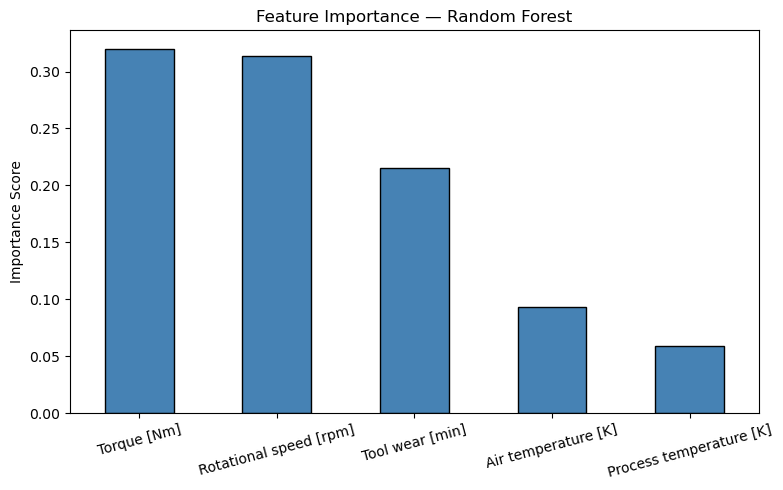

In [5]:
# Which features does the model rely on most?
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

importance.plot(kind='bar', color='steelblue', edgecolor='black', figsize=(8,5))
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Interpretation

The Random Forest feature importance chart shows that `Torque [Nm]` is the most important feature for predicting machine failure. `Rotational speed [rpm]` is the second most important feature, followed by `Tool wear [min]`.

Air temperature and process temperature have lower importance scores, meaning the model used them less compared with the other features.

Overall, the model relies mostly on torque, rotational speed, and tool wear to predict machine failure.

## Week 3 Summary — Key Findings

| Metric | No Failure | Failure |
|--------|-----------|---------|
| Precision | 0.99 | 0.89 |
| Recall | 1.00 | 0.57 |
| F1-Score | 0.99 | 0.70 |
| Support | 1932 | 68 |

| | Predicted No Failure | Predicted Failure |
|---|---|---|
| **Actual No Failure** | 1927 ✅ | 5 ❌ |
| **Actual Failure** | 29 ❌ | 39 ✅ |

| Rank | Feature | Importance |
|------|---------|------------|
| 1 | Torque [Nm] | 32.0% |
| 2 | Rotational speed [rpm] | 31.3% |
| 3 | Tool wear [min] | 21.5% |
| 4 | Air temperature [K] | 9.3% |
| 5 | Process temperature [K] | 5.9% |

### Key Takeaways
- **Precision 0.89** — when model raises a failure alert, it is correct 89% of the time
- **Recall 0.57** — model only catches 57% of actual failures, missing 29 real cases
- **Torque and Rotational speed** drive 63% of all model decisions
- Rotational speed had low correlation in Week 2 but ranks 2nd in feature importance — Random Forest detects non-linear patterns that correlation cannot
- **Next step (Week 4):** Tune the model threshold to improve Recall and catch more failures

---